# Lab 21 - LoRA / QLoRA Fine-tuning on Colab T4

This notebook is a robust Colab T4 implementation for the Lab 21 rubric.

It trains LoRA adapters with ranks `r=8`, `r=16`, and `r=64`, evaluates perplexity, generates qualitative comparisons, saves adapters/results, writes `REPORT.md`, and includes bonus paths for all-layer LoRA and HuggingFace Hub.

Important design choice: the training loop is implemented manually with Unsloth + PEFT + PyTorch instead of relying on `TRL SFTTrainer`. Recent Colab/Unsloth/TRL combinations have changed `SFTConfig` defaults and can fail on T4 with bf16/eos-token issues. This notebook keeps the same SFT behavior but avoids those unstable trainer APIs.

## Rubric Coverage

| Requirement | Covered by |
|---|---|
| Dataset prep Alpaca format, 100-500 samples | Cells 5-7 |
| Token p95 and max sequence length | Cell 7 |
| Train LoRA ranks 8, 16, 64 | Cells 9-10 |
| Same dataset/hyperparameters across ranks | Shared config in Cell 1 |
| Metrics: time, VRAM, params, perplexity | Cells 9-11 |
| Qualitative 5 examples | Cells 13-14 |
| Report with 6 sections | Cell 17 |
| Bonus HF Hub | Cell 16 |
| Bonus all-layer LoRA | Cell 15 |

In [19]:
#@title 1. Configuration
from pathlib import Path

STUDENT_NAME = "Dien ten cua ban"
STUDENT_ID = "MSSV"
SUBMISSION_OPTION = "B"  # A lightweight, B HF Hub bonus, C code-only

MODEL_NAME = "unsloth/Qwen2.5-3B-bnb-4bit"
DATASET_NAME = "5CD-AI/Vietnamese-alpaca-gpt4-gg-translated"
DATASET_SPLIT = "train"

FAST_DEBUG = False
NUM_SAMPLES = 36 if FAST_DEBUG else 200
EVAL_RATIO = 0.10
RANDOM_SEED = 42

MAX_SEQ_CAP = 1024
MIN_SEQ_LENGTH = 256

RANK_CONFIGS = [
    {"rank": 8, "alpha": 16, "label": "r8"},
    {"rank": 16, "alpha": 32, "label": "r16"},
    {"rank": 64, "alpha": 128, "label": "r64"},
]

BASE_TARGET_MODULES = ["q_proj", "v_proj"]
ALL_LAYER_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

RUN_STRETCH_ALL_LAYERS = True

# Bonus Option B: HuggingFace Hub
PUSH_TO_HUB = True
HF_USERNAME = "Sfsfsfdfd"
HF_REPO_PREFIX = "lab21-qwen25-3b-lora"
GITHUB_REPO_URL = "https://github.com/104221795/Day21-2A202600331-Track3-Finetuning-LLMs-LoRA-QLoRA"

NUM_EPOCHS = 1 if FAST_DEBUG else 3
PER_DEVICE_TRAIN_BATCH_SIZE = 1
PER_DEVICE_EVAL_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 8
LEARNING_RATE = 2e-4
WARMUP_RATIO = 0.10
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0

OUTPUT_DIR = Path("lab21_submission")
ADAPTER_DIR = OUTPUT_DIR / "adapters"
RESULTS_DIR = OUTPUT_DIR / "results"
for path in [OUTPUT_DIR, ADAPTER_DIR, RESULTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Config ready")
print(f"FAST_DEBUG={FAST_DEBUG}, samples={NUM_SAMPLES}, epochs={NUM_EPOCHS}")
print(f"PUSH_TO_HUB={PUSH_TO_HUB}, HF_USERNAME={HF_USERNAME}")
print(f"GitHub repo={GITHUB_REPO_URL}")
print(f"Output folder: {OUTPUT_DIR.resolve()}")


Config ready
FAST_DEBUG=False, samples=200, epochs=3
PUSH_TO_HUB=True, HF_USERNAME=Sfsfsfdfd
GitHub repo=https://github.com/104221795/Day21-2A202600331-Track3-Finetuning-LLMs-LoRA-QLoRA
Output folder: /content/lab21_submission


In [2]:
#@title 2. GPU check
import sys, platform, subprocess

print("Python:", sys.version)
print("Platform:", platform.platform())
print("\n--- nvidia-smi ---")
result = subprocess.run("nvidia-smi", shell=True, text=True, capture_output=True)
print(result.stdout if result.returncode == 0 else result.stderr)

import torch
assert torch.cuda.is_available(), "Colab GPU is required. Use Runtime > Change runtime type > GPU."
gpu_name = torch.cuda.get_device_name(0)
major, minor = torch.cuda.get_device_capability(0)
total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU: {gpu_name}, compute capability={major}.{minor}, VRAM={total_vram:.2f} GB")
print(f"bf16 supported: {torch.cuda.is_bf16_supported()}")
print("Precision decision: T4 uses fp16=True, bf16=False")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35

--- nvidia-smi ---
Thu May  7 05:16:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|             

In [3]:
#@title 3. Install dependencies
# Keep logs visible. If install fails, read the exact pip error.
import sys, subprocess

def pip_install(*packages):
    cmd = [sys.executable, "-m", "pip", "install", "-U"] + list(packages)
    print("\n$ " + " ".join(cmd))
    subprocess.check_call(cmd)

subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "pip", "setuptools", "wheel"])

# Remove packages from previous failed sessions.
subprocess.call([
    sys.executable, "-m", "pip", "uninstall", "-y",
    "transformers", "trl", "peft", "accelerate", "bitsandbytes", "unsloth", "unsloth_zoo"
])

# Stable stack for manual SFT on Colab T4.
pip_install(
    "transformers>=4.46,<5.0",
    "peft>=0.13",
    "accelerate>=0.34",
    "bitsandbytes>=0.43",
    "datasets",
    "sentencepiece",
    "protobuf",
    "safetensors",
    "pandas",
    "matplotlib",
    "seaborn",
    "tabulate",
)
pip_install("unsloth")

print("\nDependencies installed.")
print("If Colab asks for a runtime restart, restart and continue from cell 4.")


$ /usr/bin/python3 -m pip install -U transformers>=4.46,<5.0 peft>=0.13 accelerate>=0.34 bitsandbytes>=0.43 datasets sentencepiece protobuf safetensors pandas matplotlib seaborn tabulate

$ /usr/bin/python3 -m pip install -U unsloth

Dependencies installed.
If Colab asks for a runtime restart, restart and continue from cell 4.


In [4]:
#@title 4. Imports and reproducibility
import gc
import json
import math
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from datasets import Dataset, load_dataset
from transformers import AutoTokenizer, get_cosine_schedule_with_warmup
from peft import PeftModel
from unsloth import FastLanguageModel

try:
    import bitsandbytes as bnb
    HAS_BNB = True
except Exception:
    HAS_BNB = False

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

print("Imports ready")
print("torch:", torch.__version__)
print("bitsandbytes available:", HAS_BNB)

/tmp/ipykernel_3600/2535138930.py:19: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Imports ready
torch: 2.10.0+cu128
bitsandbytes available: True


## 1. Dataset Preparation

In [5]:
#@title 5. Load source dataset
raw = load_dataset(DATASET_NAME, split=DATASET_SPLIT)
raw = raw.shuffle(seed=RANDOM_SEED)
raw = raw.select(range(min(len(raw), NUM_SAMPLES * 3)))

print("Raw samples:", len(raw))
print("Columns:", raw.column_names)
print(raw[0])

README.md:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

alpaca_gpt4_data_vi.json:   0%|          | 0.00/102M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

Raw samples: 600
Columns: ['input_en', 'input_vi', 'instruction_vi', 'output_vi', 'output_en', 'instruction_en']
{'input_en': '', 'input_vi': '', 'instruction_vi': 'Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.', 'output_vi': 'Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (điện, nước, gas): $150 - Hàng tạp hóa: $300 - Bảo hiểm (sức khỏe, xe hơi, người thuê nhà, v.v. ): $200 - Đi lại (thanh toán ô tô, xăng, phương tiện công cộng): $225 - Mong muốn (30% thu nhập): $1050 - Ăn uống và giải trí: $300 - Chi phí mua sắm và cá nhân: $300 - Du lịch và sở thích: $250 - Linh tinh (đăng ký , thành viên): $200 - Tiết kiệm và trả nợ (20% thu nhập): $700 - Quỹ khẩn cấp: $200 - Quỹ hưu trí: $300 - Trả nợ (thẻ tín dụng, khoản vay sin

In [6]:
#@title 6. Clean and format Alpaca data
ALPACA_TEMPLATE = """### Instruction:
{instruction}

### Input:
{input}

### Response:
{output}"""

ALPACA_TEMPLATE_NO_INPUT = """### Instruction:
{instruction}

### Response:
{output}"""

def pick_column(columns, candidates):
    return next((c for c in candidates if c in columns), None)

cols = raw.column_names
INSTRUCTION_COL = pick_column(cols, ["instruction", "instruction_vi", "prompt", "question", "query"])
INPUT_COL = pick_column(cols, ["input", "input_vi", "context"])
OUTPUT_COL = pick_column(cols, ["output", "output_vi", "response", "answer", "completion"])
assert INSTRUCTION_COL and OUTPUT_COL, f"Cannot find instruction/output columns in {cols}"

def norm(x):
    if x is None:
        return ""
    return " ".join(str(x).strip().split())

def format_row(example):
    instruction = norm(example.get(INSTRUCTION_COL, ""))
    inp = norm(example.get(INPUT_COL, "")) if INPUT_COL else ""
    output = norm(example.get(OUTPUT_COL, ""))
    if inp:
        text = ALPACA_TEMPLATE.format(instruction=instruction, input=inp, output=output)
    else:
        text = ALPACA_TEMPLATE_NO_INPUT.format(instruction=instruction, output=output)
    return {
        "instruction": instruction,
        "input": inp,
        "output": output,
        "text": text,
        "output_token_rough": len(output.split()),
    }

formatted = raw.map(format_row, remove_columns=raw.column_names)
df = formatted.to_pandas()
df = df[df["instruction"].str.len() > 0]
df = df[df["output"].str.len() > 0]
df = df[df["output_token_rough"] >= 10]
df = df.drop_duplicates(subset=["instruction", "input", "output"]).head(NUM_SAMPLES).reset_index(drop=True)
assert len(df) >= 100 or FAST_DEBUG, f"Need at least 100 cleaned examples for final run, got {len(df)}"

ds = Dataset.from_pandas(df, preserve_index=False)
print("Cleaned samples:", len(ds))
print(ds[0]["text"][:900])

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Cleaned samples: 200
### Instruction:
Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.

### Response:
Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (điện, nước, gas): $150 - Hàng tạp hóa: $300 - Bảo hiểm (sức khỏe, xe hơi, người thuê nhà, v.v. ): $200 - Đi lại (thanh toán ô tô, xăng, phương tiện công cộng): $225 - Mong muốn (30% thu nhập): $1050 - Ăn uống và giải trí: $300 - Chi phí mua sắm và cá nhân: $300 - Du lịch và sở thích: $250 - Linh tinh (đăng ký , thành viên): $200 - Tiết kiệm và trả nợ (20% thu nhập): $700 - Quỹ khẩn cấp: $200 - Quỹ hưu trí: $300 - Trả nợ (thẻ tín dụng, khoản vay sinh viên, v.v.): $200 Ngân sách này đóng vai trò là


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

Token length: min=28, max=738, p50=236, p95=564, p99=704
Chosen max_seq_length=1024


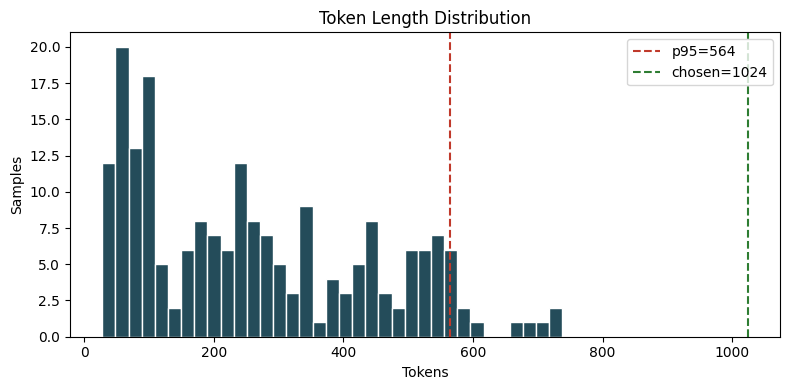

Train=180 | Eval=20


In [7]:
#@title 7. Token length analysis and train/eval split
length_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if length_tokenizer.pad_token is None:
    length_tokenizer.pad_token = length_tokenizer.eos_token or "<|endoftext|>"

lengths = [len(length_tokenizer.encode(row["text"])) for row in ds]
p50 = int(np.percentile(lengths, 50))
p95 = int(np.percentile(lengths, 95))
p99 = int(np.percentile(lengths, 99))
max_seq_length = min(MAX_SEQ_CAP, 1 << (max(p95, MIN_SEQ_LENGTH) - 1).bit_length())

print(f"Token length: min={min(lengths)}, max={max(lengths)}, p50={p50}, p95={p95}, p99={p99}")
print(f"Chosen max_seq_length={max_seq_length}")

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=35, color="#244c5a", edgecolor="white")
plt.axvline(p95, color="#c0392b", linestyle="--", label=f"p95={p95}")
plt.axvline(max_seq_length, color="#2e7d32", linestyle="--", label=f"chosen={max_seq_length}")
plt.xlabel("Tokens")
plt.ylabel("Samples")
plt.title("Token Length Distribution")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "token_length_distribution.png", dpi=160)
plt.show()

split = ds.train_test_split(test_size=EVAL_RATIO, seed=RANDOM_SEED)
train_ds = split["train"]
eval_ds = split["test"]
print(f"Train={len(train_ds)} | Eval={len(eval_ds)}")

## 2. Manual SFT Training Helpers

In [8]:
#@title 8. Model, tokenizer, dataloader, and utility helpers
def cleanup_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def load_base_model():
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_NAME,
        max_seq_length=max_seq_length,
        dtype=None,
        load_in_4bit=True,
    )
    if tokenizer.eos_token is None:
        tokenizer.eos_token = "<|endoftext|>"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    return model, tokenizer

def wrap_with_lora(model, rank, alpha, target_modules):
    return FastLanguageModel.get_peft_model(
        model,
        r=rank,
        lora_alpha=alpha,
        target_modules=target_modules,
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=RANDOM_SEED,
    )

def count_trainable_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total, 100 * trainable / total

def tokenize_dataset(dataset, tokenizer):
    eos = tokenizer.eos_token or ""

    def tok(batch):
        texts = [x + eos for x in batch["text"]]
        out = tokenizer(
            texts,
            truncation=True,
            max_length=max_seq_length,
            padding=False,
        )
        return out

    keep_cols = dataset.column_names
    return dataset.map(tok, batched=True, remove_columns=keep_cols)

def make_collator(tokenizer):
    def collate(features):
        batch = tokenizer.pad(features, padding=True, return_tensors="pt")
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        batch["labels"] = labels
        return batch
    return collate

def make_optimizer(model):
    params = [p for p in model.parameters() if p.requires_grad]
    if HAS_BNB:
        return bnb.optim.AdamW8bit(params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    return torch.optim.AdamW(params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

def precision_dtype():
    return torch.float16

print("Helpers ready")

Helpers ready


In [9]:
#@title 9. Train/eval/generate functions
def evaluate_loss(model, dataloader):
    cleanup_cuda()
    model.eval()
    losses = []
    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(model.device) for k, v in batch.items()}
            with torch.amp.autocast("cuda", dtype=precision_dtype()):
                out = model(**batch)
            losses.append(float(out.loss.detach().cpu()))
            del out, batch
            cleanup_cuda()
    mean_loss = float(np.mean(losses)) if losses else float("nan")
    ppl = float(math.exp(mean_loss)) if math.isfinite(mean_loss) and mean_loss < 20 else float("inf")
    return mean_loss, ppl

def train_one_rank(rank, alpha, label, target_modules):
    print("\n" + "=" * 90)
    print(f"Training {label}: rank={rank}, alpha={alpha}, target_modules={target_modules}")
    print("=" * 90)
    cleanup_cuda()
    torch.cuda.reset_peak_memory_stats()

    model, tokenizer = load_base_model()
    model = wrap_with_lora(model, rank=rank, alpha=alpha, target_modules=target_modules)
    trainable, total, pct = count_trainable_params(model)
    print(f"Trainable params: {trainable:,} / {total:,} ({pct:.4f}%)")

    tokenized_train = tokenize_dataset(train_ds, tokenizer)
    tokenized_eval = tokenize_dataset(eval_ds, tokenizer)
    collator = make_collator(tokenizer)
    train_loader = DataLoader(tokenized_train, batch_size=PER_DEVICE_TRAIN_BATCH_SIZE, shuffle=True, collate_fn=collator)
    eval_loader = DataLoader(tokenized_eval, batch_size=PER_DEVICE_EVAL_BATCH_SIZE, shuffle=False, collate_fn=collator)

    optimizer = make_optimizer(model)
    total_update_steps = math.ceil(len(train_loader) * NUM_EPOCHS / GRADIENT_ACCUMULATION_STEPS)
    warmup_steps = max(1, int(WARMUP_RATIO * total_update_steps))
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_update_steps,
    )

    log_rows = []
    global_step = 0
    optimizer.zero_grad(set_to_none=True)
    t0 = time.time()

    model.train()
    for epoch in range(NUM_EPOCHS):
        running = []
        for step, batch in enumerate(train_loader, start=1):
            batch = {k: v.to(model.device) for k, v in batch.items()}
            with torch.amp.autocast("cuda", dtype=precision_dtype()):
                out = model(**batch)
                loss = out.loss / GRADIENT_ACCUMULATION_STEPS
            loss.backward()
            running.append(float(loss.detach().cpu()) * GRADIENT_ACCUMULATION_STEPS)

            if step % GRADIENT_ACCUMULATION_STEPS == 0 or step == len(train_loader):
                torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], MAX_GRAD_NORM)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)
                global_step += 1

                if global_step % 5 == 0 or global_step == 1:
                    avg_loss = float(np.mean(running[-GRADIENT_ACCUMULATION_STEPS:]))
                    lr = scheduler.get_last_lr()[0]
                    print(f"{label} | epoch {epoch+1}/{NUM_EPOCHS} | update {global_step}/{total_update_steps} | loss={avg_loss:.4f} | lr={lr:.2e}")
                    log_rows.append({"label": label, "epoch": epoch + 1, "step": global_step, "loss": avg_loss, "lr": lr})

            del out, batch, loss

    train_time_min = (time.time() - t0) / 60
    peak_vram_gb = torch.cuda.max_memory_allocated() / 1e9

    adapter_path = ADAPTER_DIR / label
    model.save_pretrained(str(adapter_path))
    tokenizer.save_pretrained(str(adapter_path))
    print(f"Saved adapter: {adapter_path}")

    eval_loss, eval_ppl = evaluate_loss(model, eval_loader)
    print(f"{label} eval_loss={eval_loss:.4f}, perplexity={eval_ppl:.2f}, time={train_time_min:.2f} min, peak_vram={peak_vram_gb:.2f} GB")

    log_df = pd.DataFrame(log_rows)
    log_path = RESULTS_DIR / f"loss_log_{label}.csv"
    log_df.to_csv(log_path, index=False)

    metrics = {
        "label": label,
        "rank": rank,
        "alpha": alpha,
        "target_modules": ",".join(target_modules),
        "trainable_params": int(trainable),
        "trainable_pct": pct,
        "train_time_min": train_time_min,
        "peak_vram_gb": peak_vram_gb,
        "eval_loss": eval_loss,
        "eval_perplexity": eval_ppl,
        "adapter_path": str(adapter_path),
        "loss_log_path": str(log_path),
    }

    del model, tokenizer, optimizer, scheduler, train_loader, eval_loader
    cleanup_cuda()
    return metrics

def generate_response(model, tokenizer, prompt, max_new_tokens=180):
    FastLanguageModel.for_inference(model)
    text = ALPACA_TEMPLATE_NO_INPUT.format(instruction=prompt, output="")
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    decoded = tokenizer.decode(out[0], skip_special_tokens=True)
    return decoded.split("### Response:")[-1].strip()

print("Training functions ready")

Training functions ready


## 3. Required Rank Experiment

In [10]:
#@title 10. Run required ranks: r8, r16, r64
required_results = []
for cfg in RANK_CONFIGS:
    metrics = train_one_rank(
        rank=cfg["rank"],
        alpha=cfg["alpha"],
        label=cfg["label"],
        target_modules=BASE_TARGET_MODULES,
    )
    required_results.append(metrics)
    partial_df = pd.DataFrame(required_results).sort_values("rank").reset_index(drop=True)
    partial_df.to_csv(RESULTS_DIR / "rank_experiment_summary_partial.csv", index=False)
    display(partial_df)

summary_df = pd.DataFrame(required_results).sort_values("rank").reset_index(drop=True)
summary_path = RESULTS_DIR / "rank_experiment_summary.csv"
summary_df.to_csv(summary_path, index=False)
display(summary_df)
print("Saved:", summary_path)


Training r8: rank=8, alpha=16, target_modules=['q_proj', 'v_proj']
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/171 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

r64 | epoch 1/3 | update 1/68 | loss=1.7924 | lr=3.33e-05
r64 | epoch 1/3 | update 5/68 | loss=1.8825 | lr=1.67e-04
r64 | epoch 1/3 | update 10/68 | loss=1.8834 | lr=1.98e-04
r64 | epoch 1/3 | update 15/68 | loss=1.6457 | lr=1.90e-04
r64 | epoch 1/3 | update 20/68 | loss=1.5201 | lr=1.76e-04
r64 | epoch 2/3 | update 25/68 | loss=1.2528 | lr=1.57e-04
r64 | epoch 2/3 | update 30/68 | loss=1.2551 | lr=1.35e-04
r64 | epoch 2/3 | update 35/68 | loss=1.1848 | lr=1.10e-04
r64 | epoch 2/3 | update 40/68 | loss=1.1544 | lr=8.49e-05
r64 | epoch 2/3 | update 45/68 | loss=1.3124 | lr=6.06e-05
r64 | epoch 3/3 | update 50/68 | loss=1.1882 | lr=3.88e-05
r64 | epoch 3/3 | update 55/68 | loss=1.4039 | lr=2.09e-05
r64 | epoch 3/3 | update 60/68 | loss=1.2899 | lr=8.10e-06
r64 | epoch 3/3 | update 65/68 | loss=1.4578 | lr=1.15e-06
Saved adapter: lab21_submission/adapters/r64
r64 eval_loss=1.4768, perplexity=4.38, time=5.02 min, peak_vram=2.52 GB


,label,rank,alpha,target_modules,trainable_params,trainable_pct,train_time_min,peak_vram_gb,eval_loss,eval_perplexity,adapter_path,loss_log_path
0,r8,8,16,"q_proj,v_proj",1843200,0.108391,5.396420,3.099768,1.547841,4.701309,lab21_submission/adapters/r8,lab21_submission/results/loss_log_r8.csv
1,r16,16,32,"q_proj,v_proj",3686400,0.216547,5.109731,2.385334,1.509249,4.523331,lab21_submission/adapters/r16,lab21_submission/results/loss_log_r16.csv
2,r64,64,128,"q_proj,v_proj",14745600,0.860595,5.021165,2.518376,1.476797,4.378899,lab21_submission/adapters/r64,lab21_submission/results/loss_log_r64.csv


,label,rank,alpha,target_modules,trainable_params,trainable_pct,train_time_min,peak_vram_gb,eval_loss,eval_perplexity,adapter_path,loss_log_path
0,r8,8,16,"q_proj,v_proj",1843200,0.108391,5.396420,3.099768,1.547841,4.701309,lab21_submission/adapters/r8,lab21_submission/results/loss_log_r8.csv
1,r16,16,32,"q_proj,v_proj",3686400,0.216547,5.109731,2.385334,1.509249,4.523331,lab21_submission/adapters/r16,lab21_submission/results/loss_log_r16.csv
2,r64,64,128,"q_proj,v_proj",14745600,0.860595,5.021165,2.518376,1.476797,4.378899,lab21_submission/adapters/r64,lab21_submission/results/loss_log_r64.csv


Saved: lab21_submission/results/rank_experiment_summary.csv


In [11]:
#@title 11. Evaluate base model perplexity
cleanup_cuda()
base_model, base_tokenizer = load_base_model()
tokenized_eval = tokenize_dataset(eval_ds, base_tokenizer)
eval_loader = DataLoader(tokenized_eval, batch_size=PER_DEVICE_EVAL_BATCH_SIZE, shuffle=False, collate_fn=make_collator(base_tokenizer))
base_eval_loss, base_eval_ppl = evaluate_loss(base_model, eval_loader)
print(f"Base eval_loss={base_eval_loss:.4f}, perplexity={base_eval_ppl:.2f}")
del base_model, base_tokenizer, eval_loader
cleanup_cuda()

base_row = {
    "label": "base",
    "rank": "base",
    "alpha": "-",
    "target_modules": "-",
    "trainable_params": 0,
    "trainable_pct": 0.0,
    "train_time_min": 0.0,
    "peak_vram_gb": np.nan,
    "eval_loss": base_eval_loss,
    "eval_perplexity": base_eval_ppl,
    "adapter_path": "-",
    "loss_log_path": "-",
}

full_summary_df = pd.concat([pd.DataFrame([base_row]), summary_df], ignore_index=True)
full_summary_path = RESULTS_DIR / "rank_experiment_summary_with_base.csv"
full_summary_df.to_csv(full_summary_path, index=False)
display(full_summary_df)
print("Saved:", full_summary_path)

==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Base eval_loss=1.8350, perplexity=6.27


,label,rank,alpha,target_modules,trainable_params,trainable_pct,train_time_min,peak_vram_gb,eval_loss,eval_perplexity,adapter_path,loss_log_path
0,base,base,-,-,0,0.000000,0.000000,NaN,1.835039,6.265381,-,-
1,r8,8,16,"q_proj,v_proj",1843200,0.108391,5.396420,3.099768,1.547841,4.701309,lab21_submission/adapters/r8,lab21_submission/results/loss_log_r8.csv
2,r16,16,32,"q_proj,v_proj",3686400,0.216547,5.109731,2.385334,1.509249,4.523331,lab21_submission/adapters/r16,lab21_submission/results/loss_log_r16.csv
3,r64,64,128,"q_proj,v_proj",14745600,0.860595,5.021165,2.518376,1.476797,4.378899,lab21_submission/adapters/r64,lab21_submission/results/loss_log_r64.csv


Saved: lab21_submission/results/rank_experiment_summary_with_base.csv


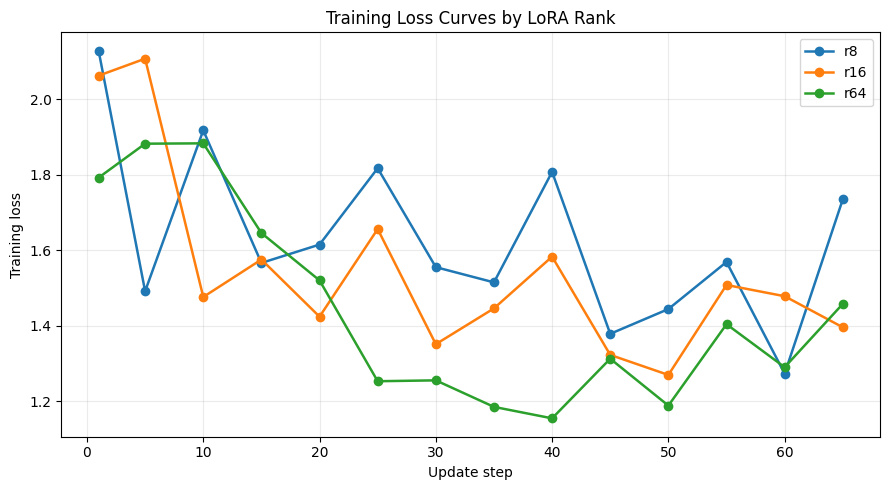

Saved: lab21_submission/results/loss_curve.png


In [12]:
#@title 12. Plot loss curves
plt.figure(figsize=(9, 5))
for label in ["r8", "r16", "r64"]:
    path = RESULTS_DIR / f"loss_log_{label}.csv"
    if not path.exists():
        continue
    log_df = pd.read_csv(path)
    if len(log_df):
        plt.plot(log_df["step"], log_df["loss"], marker="o", linewidth=1.8, label=label)

plt.xlabel("Update step")
plt.ylabel("Training loss")
plt.title("Training Loss Curves by LoRA Rank")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
loss_curve_path = RESULTS_DIR / "loss_curve.png"
plt.savefig(loss_curve_path, dpi=180)
plt.show()
print("Saved:", loss_curve_path)

## 4. Qualitative Evaluation

In [13]:
#@title 13. Test prompts
TEST_PROMPTS = [
    "Giải thích khái niệm machine learning cho người mới bắt đầu.",
    "Viết đoạn code Python tính số Fibonacci thứ n.",
    "Liệt kê 5 nguyên tắc thiết kế UI/UX quan trọng.",
    "Tóm tắt sự khác biệt giữa LoRA và QLoRA.",
    "Phân biệt prompt engineering, RAG, và fine-tuning.",
]
print(f"Prepared {len(TEST_PROMPTS)} prompts")

Prepared 5 prompts


In [14]:
#@title 14. Generate base vs r16 qualitative comparison
cleanup_cuda()
base_model, eval_tokenizer = load_base_model()
ft_model = PeftModel.from_pretrained(base_model, str(ADAPTER_DIR / "r16"))

qualitative_rows = []
for i, prompt in enumerate(TEST_PROMPTS, start=1):
    print("\n" + "-" * 80)
    print(f"Prompt {i}: {prompt}")
    base_response = generate_response(base_model, eval_tokenizer, prompt)
    ft_response = generate_response(ft_model, eval_tokenizer, prompt)
    print("BASE:", base_response[:700])
    print("R16 :", ft_response[:700])
    qualitative_rows.append({
        "example": i,
        "prompt": prompt,
        "base_response": base_response,
        "finetuned_r16_response": ft_response,
        "comment": "Fill after reading outputs: improved / same / degraded and why.",
    })

qual_df = pd.DataFrame(qualitative_rows)
qual_path = RESULTS_DIR / "qualitative_comparison.csv"
qual_df.to_csv(qual_path, index=False)
display(qual_df)
print("Saved:", qual_path)

del ft_model, base_model, eval_tokenizer
cleanup_cuda()

==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.

--------------------------------------------------------------------------------
Prompt 1: Giải thích khái niệm machine learning cho người mới bắt đầu.
BASE: Machine learning là một phân khúc của trí tuệ nhân tạo, nó tập trung vào việc học từ dữ liệu và tự cải thiện qua thời gian thay vì dựa trên các quy tắc cứng nhắc. Nhìn vào cơ bản, mục tiêu của machine learning là giúp máy học các mô hình dựa trên dữ liệu mà không cần phải được chỉ định bằng các

,example,prompt,base_response,finetuned_r16_response,comment
0,1,Giải thích khái niệm machine learning cho ngườ...,Machine learning là một phân khúc của trí tuệ ...,Machine learning là một phương pháp tính toán ...,Fill after reading outputs: improved / same / ...
1,2,Viết đoạn code Python tính số Fibonacci thứ n.,"Để tính số Fibonacci thứ n bằng Python, bạn có...","Để tính số Fibonacci thứ n trong Python, chúng...",Fill after reading outputs: improved / same / ...
2,3,Liệt kê 5 nguyên tắc thiết kế UI/UX quan trọng.,1. **Giới thiệu dễ hiểu**: UI/UX thiết kế nên ...,1. Phân tích nhu cầu người dùng: Trước khi thi...,Fill after reading outputs: improved / same / ...
3,4,Tóm tắt sự khác biệt giữa LoRA và QLoRA.,LoRA (Large Language Models Optimized for Low-...,LoRA (Low-Rank Adaptation) và QLoRA (Quantized...,Fill after reading outputs: improved / same / ...
4,5,"Phân biệt prompt engineering, RAG, và fine-tun...","Prompt engineering, RAG và fine-tuning là các ...","Prompt engineering, RAG, và fine-tuning là ba ...",Fill after reading outputs: improved / same / ...


Saved: lab21_submission/results/qualitative_comparison.csv


## 5. Bonus

In [15]:
#@title 15. Bonus stretch: r16 target all layers
stretch_results = []
if RUN_STRETCH_ALL_LAYERS:
    stretch_metrics = train_one_rank(
        rank=16,
        alpha=32,
        label="r16_all_layers",
        target_modules=ALL_LAYER_MODULES,
    )
    stretch_results.append(stretch_metrics)
    stretch_df = pd.DataFrame(stretch_results)
    stretch_path = RESULTS_DIR / "stretch_experiment_summary.csv"
    stretch_df.to_csv(stretch_path, index=False)
    display(stretch_df)
    print("Saved:", stretch_path)
else:
    print("RUN_STRETCH_ALL_LAYERS=False, skipping stretch bonus.")


Training r16_all_layers: rank=16, alpha=32, target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.5.2 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


Trainable params: 29,933,568 / 1,728,606,208 (1.7317%)


Map:   0%|          | 0/180 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

r16_all_layers | epoch 1/3 | update 1/68 | loss=1.7430 | lr=3.33e-05
r16_all_layers | epoch 1/3 | update 5/68 | loss=1.5350 | lr=1.67e-04
r16_all_layers | epoch 1/3 | update 10/68 | loss=1.4915 | lr=1.98e-04
r16_all_layers | epoch 1/3 | update 15/68 | loss=1.3879 | lr=1.90e-04
r16_all_layers | epoch 1/3 | update 20/68 | loss=1.5742 | lr=1.76e-04
r16_all_layers | epoch 2/3 | update 25/68 | loss=1.2147 | lr=1.57e-04
r16_all_layers | epoch 2/3 | update 30/68 | loss=1.1841 | lr=1.35e-04
r16_all_layers | epoch 2/3 | update 35/68 | loss=1.4158 | lr=1.10e-04
r16_all_layers | epoch 2/3 | update 40/68 | loss=1.1856 | lr=8.49e-05
r16_all_layers | epoch 2/3 | update 45/68 | loss=1.2532 | lr=6.06e-05
r16_all_layers | epoch 3/3 | update 50/68 | loss=0.7706 | lr=3.88e-05
r16_all_layers | epoch 3/3 | update 55/68 | loss=1.0603 | lr=2.09e-05
r16_all_layers | epoch 3/3 | update 60/68 | loss=1.1358 | lr=8.10e-06
r16_all_layers | epoch 3/3 | update 65/68 | loss=1.0817 | lr=1.15e-06
Saved adapter: lab21_s

,label,rank,alpha,target_modules,trainable_params,trainable_pct,train_time_min,peak_vram_gb,eval_loss,eval_perplexity,adapter_path,loss_log_path
0,r16_all_layers,16,32,"q_proj,k_proj,v_proj,o_proj,gate_proj,up_proj,...",29933568,1.731659,5.574125,2.698437,1.485497,4.41716,lab21_submission/adapters/r16_all_layers,lab21_submission/results/loss_log_r16_all_laye...


Saved: lab21_submission/results/stretch_experiment_summary.csv


In [21]:
#@title 16. Bonus Option B: push best adapter to HuggingFace Hub
# Security note: never hardcode your HuggingFace token in the notebook.
# Recommended: Colab left sidebar > Secrets > add key HF_TOKEN with a WRITE token.
# Fallback: this cell will ask for the token via a hidden getpass prompt.
if PUSH_TO_HUB:
    import getpass
    from pathlib import Path
    from huggingface_hub import login

    assert "summary_df" in globals(), "Run the rank experiment cell before pushing to Hub."
    assert HF_USERNAME and HF_USERNAME != "your-hf-username", "Set HF_USERNAME in cell 1."
    assert GITHUB_REPO_URL.startswith("https://github.com/"), "Set a valid GitHub repo URL in cell 1."

    hf_token = None
    try:
        from google.colab import userdata
        hf_token = userdata.get("HF_TOKEN")
        if hf_token:
            print("Loaded HF_TOKEN from Colab Secrets.")
    except Exception:
        hf_token = None

    if not hf_token:
        hf_token = getpass.getpass("Paste your HuggingFace WRITE token: ")

    login(token=hf_token, add_to_git_credential=False)

    best_row = summary_df.sort_values("eval_perplexity", na_position="last").iloc[0]
    best_label = str(best_row["label"])
    adapter_path = ADAPTER_DIR / best_label
    assert adapter_path.exists(), f"Adapter folder not found: {adapter_path}. Train ranks before pushing."

    repo_id = f"{HF_USERNAME}/{HF_REPO_PREFIX}-{best_label}"
    print("Best adapter by eval perplexity:", best_label)
    print("Pushing adapter to:", f"https://huggingface.co/{repo_id}")

    model, tokenizer = load_base_model()
    model = PeftModel.from_pretrained(model, str(adapter_path))
    model.push_to_hub(repo_id, private=False)
    tokenizer.push_to_hub(repo_id, private=False)

    links = OUTPUT_DIR / "LINKS.md"
    links.write_text(
        f"# Lab 21 Links\n\n"
        f"- HuggingFace adapter: https://huggingface.co/{repo_id}\n"
        f"- GitHub repo: {GITHUB_REPO_URL}\n",
        encoding="utf-8",
    )
    print("Saved:", links)

    del model, tokenizer
    cleanup_cuda()
else:
    print("PUSH_TO_HUB=False. Set PUSH_TO_HUB=True in cell 1 to enable +5 HF Hub bonus.")
    print(f"Configured HF username: {HF_USERNAME}")
    print(f"Configured GitHub repo: {GITHUB_REPO_URL}")


Paste your HuggingFace WRITE token: ··········
Best adapter by eval perplexity: r64
Pushing adapter to: https://huggingface.co/Sfsfsfdfd/lab21-qwen25-3b-lora-r64
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 9.44kB / 59.0MB            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp40qv32uh/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

Saved: lab21_submission/LINKS.md


In [22]:
print(open("lab21_submission/LINKS.md", encoding="utf-8").read())


# Lab 21 Links

- HuggingFace adapter: https://huggingface.co/Sfsfsfdfd/lab21-qwen25-3b-lora-r64
- GitHub repo: https://github.com/104221795/Day21-2A202600331-Track3-Finetuning-LLMs-LoRA-QLoRA



## 6. Auto Report and Package

In [23]:
#@title 17. Generate REPORT.md
def fmt(x, digits=4):
    try:
        if pd.isna(x):
            return "NaN"
        return f"{float(x):.{digits}f}"
    except Exception:
        return str(x)

gpu_name = torch.cuda.get_device_name(0)
gpu_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
total_minutes = float(summary_df["train_time_min"].sum())
estimated_cost = total_minutes / 60 * 0.35

rank_table = full_summary_df[["rank", "trainable_params", "train_time_min", "peak_vram_gb", "eval_loss", "eval_perplexity"]].copy()
rank_table["train_time_min"] = rank_table["train_time_min"].apply(lambda x: fmt(x, 2))
rank_table["peak_vram_gb"] = rank_table["peak_vram_gb"].apply(lambda x: fmt(x, 2))
rank_table["eval_loss"] = rank_table["eval_loss"].apply(lambda x: fmt(x, 4))
rank_table["eval_perplexity"] = rank_table["eval_perplexity"].apply(lambda x: fmt(x, 2))

best_row = summary_df.sort_values("eval_perplexity", na_position="last").iloc[0]

qual_sections = []
for _, row in qual_df.iterrows():
    qual_sections.append(f"""### Example {int(row['example'])}

**Prompt:** {row['prompt']}

**Base:** {row['base_response'][:700]}

**Fine-tuned r16:** {row['finetuned_r16_response'][:700]}

**Nhận xét:** {row['comment']}
""")

report = f"""# Lab 21 - Evaluation Report

**Học viên**: {STUDENT_NAME} - {STUDENT_ID}
**Ngày nộp**: <YYYY-MM-DD>
**Submission option**: {SUBMISSION_OPTION}

## 1. Setup

- **Base model**: `{MODEL_NAME}`
- **Dataset**: `{DATASET_NAME}`, {len(ds)} cleaned samples ({len(train_ds)} train + {len(eval_ds)} eval)
- **max_seq_length**: {max_seq_length} (p95 = {p95})
- **GPU**: {gpu_name}, {gpu_vram:.2f} GB VRAM
- **Training cost estimate**: ${estimated_cost:.2f} (~{total_minutes:.1f} min @ $0.35/hr)
- **Main LoRA target modules**: `{BASE_TARGET_MODULES}`
- **Hyperparameters**: epochs={NUM_EPOCHS}, lr={LEARNING_RATE}, cosine schedule, warmup_ratio={WARMUP_RATIO}, effective batch size={PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}

## 2. Rank Experiment Results

{rank_table.to_markdown(index=False)}

## 3. Loss Curve Analysis

Loss curve file: `results/loss_curve.png`.

The training loss curves show how quickly each LoRA rank adapts to the dataset. The final eval perplexity is used as the main quantitative comparison because mid-training eval can be expensive on T4. If `r64` has lower training loss but similar or worse eval perplexity than `r16`, that suggests diminishing returns or mild overfitting. If `r8` is close to `r16`, rank 8 may be attractive for cost-sensitive deployment.

## 4. Qualitative Comparison

{chr(10).join(qual_sections)}

## 5. Conclusion về Rank Trade-off

The best rank by eval perplexity in this run is `r={best_row['rank']}`. However, rank selection should balance quality and cost. Rank 8 trains fastest and uses the least adapter capacity, so it is useful for small datasets or many tenant-specific adapters. Rank 16 is usually the most practical default because it adds enough capacity for style and format adaptation while keeping VRAM and training time manageable. Rank 64 has much higher capacity, but on a 100-500 example dataset it may not improve perplexity enough to justify the extra time and memory. For production, I would choose rank 16 unless rank 64 gives a clear qualitative and perplexity improvement.

## 6. What I Learned

- LoRA rank controls adapter capacity, but higher rank does not guarantee better generalization.
- QLoRA makes this experiment possible on a Colab T4 by keeping the base model in 4-bit.
- Evaluation needs both perplexity and qualitative examples because a lower loss does not always mean a better user-facing answer.
"""

report_path = OUTPUT_DIR / "REPORT.md"
report_path.write_text(report, encoding="utf-8")
print(report)
print("Saved:", report_path)

# Lab 21 - Evaluation Report

**Học viên**: Dien ten cua ban - MSSV  
**Ngày nộp**: <YYYY-MM-DD>  
**Submission option**: B

## 1. Setup

- **Base model**: `unsloth/Qwen2.5-3B-bnb-4bit`
- **Dataset**: `5CD-AI/Vietnamese-alpaca-gpt4-gg-translated`, 200 cleaned samples (180 train + 20 eval)
- **max_seq_length**: 1024 (p95 = 564)
- **GPU**: Tesla T4, 15.64 GB VRAM
- **Training cost estimate**: $0.09 (~15.5 min @ $0.35/hr)
- **Main LoRA target modules**: `['q_proj', 'v_proj']`
- **Hyperparameters**: epochs=3, lr=0.0002, cosine schedule, warmup_ratio=0.1, effective batch size=8

## 2. Rank Experiment Results

| rank   |   trainable_params |   train_time_min |   peak_vram_gb |   eval_loss |   eval_perplexity |
|:-------|-------------------:|-----------------:|---------------:|------------:|------------------:|
| base   |                  0 |             0    |         nan    |      1.835  |              6.27 |
| 8      |            1843200 |             5.4  |           3.1  |      1.5478 | 

In [18]:
#@title 18. Package submission ZIP
import shutil

zip_base = f"lab21_{STUDENT_ID}_{STUDENT_NAME}".replace(" ", "")
zip_path = shutil.make_archive(zip_base, "zip", OUTPUT_DIR)
print("Created:", zip_path)
print("\nSubmission folder:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    print(path)

Created: /content/lab21_MSSV_Dientencuaban.zip

Submission folder:
lab21_submission/REPORT.md
lab21_submission/adapters
lab21_submission/adapters/r16
lab21_submission/adapters/r16/README.md
lab21_submission/adapters/r16/adapter_config.json
lab21_submission/adapters/r16/adapter_model.safetensors
lab21_submission/adapters/r16/added_tokens.json
lab21_submission/adapters/r16/merges.txt
lab21_submission/adapters/r16/special_tokens_map.json
lab21_submission/adapters/r16/tokenizer.json
lab21_submission/adapters/r16/tokenizer_config.json
lab21_submission/adapters/r16/vocab.json
lab21_submission/adapters/r16_all_layers
lab21_submission/adapters/r16_all_layers/README.md
lab21_submission/adapters/r16_all_layers/adapter_config.json
lab21_submission/adapters/r16_all_layers/adapter_model.safetensors
lab21_submission/adapters/r16_all_layers/added_tokens.json
lab21_submission/adapters/r16_all_layers/merges.txt
lab21_submission/adapters/r16_all_layers/special_tokens_map.json
lab21_submission/adapters/r

## Final Checklist

- `lab21_submission/REPORT.md`
- `lab21_submission/results/rank_experiment_summary.csv`
- `lab21_submission/results/rank_experiment_summary_with_base.csv`
- `lab21_submission/results/qualitative_comparison.csv`
- `lab21_submission/results/loss_curve.png`
- `lab21_submission/adapters/r16`
- Optional bonus: `lab21_submission/results/stretch_experiment_summary.csv`
- Optional bonus: `lab21_submission/LINKS.md`